### Loading

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import pickle
from prep_files_for_altar import main
import h5py

In [2]:
dirname = "in15"
multi, faults, datasets, trans = pickle.load(open(f"../results/inversion_results/{dirname}/inputs/csi.pickle", "rb"))
res = h5py.File(f"../results/inversion_results/{dirname}/outputs/step_final.h5", "r")

### Random sample of posterior PDFs

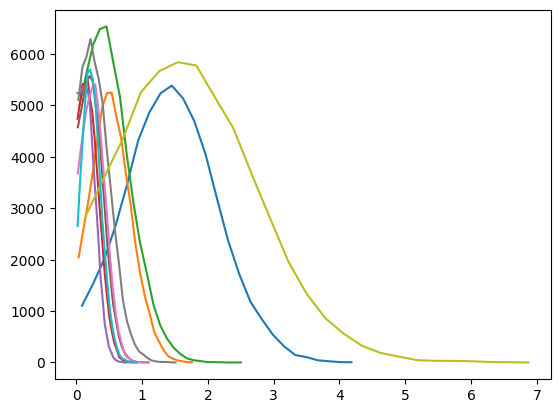

In [3]:
patch_ids = np.random.choice(253, 10, replace=False)
for id in patch_ids:
    hist = np.histogram(res["ParameterSets"]["strikeslipmain"][:,id], bins=25)
    bin_centres = (hist[1][:-1] + hist[1][1:]) / 2
    plt.plot(-bin_centres, hist[0])

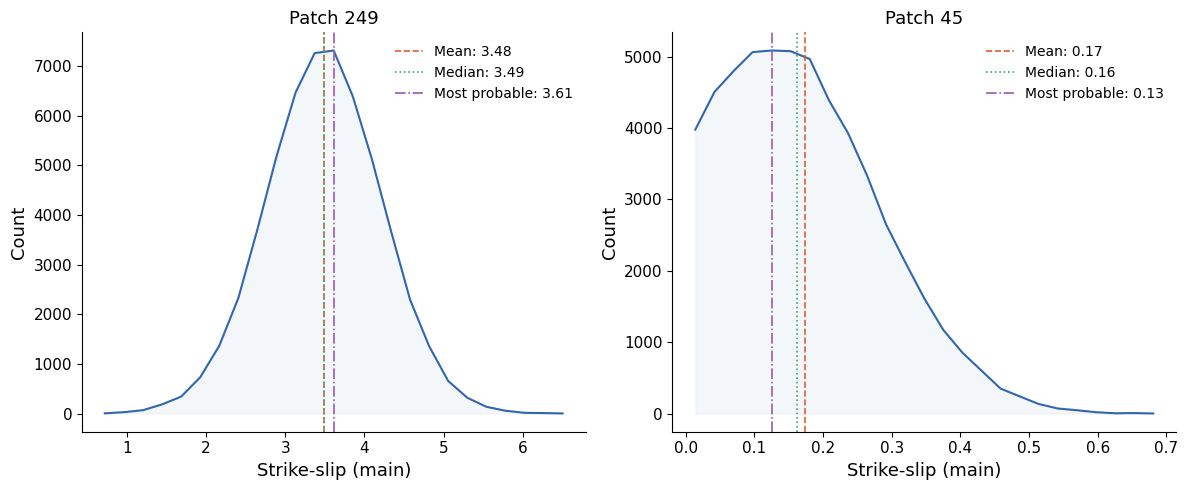

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# patch_ids = np.random.choice(253, 2, replace=False)
patch_ids = [249, 45]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, pid in zip(axes, patch_ids):
    data = -res["ParameterSets"]["strikeslipmain"][:, pid]

    counts, bin_edges = np.histogram(data, bins=25)
    bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2

    mean_val   = np.mean(data)
    median_val = np.median(data)
    mode_val   = bin_centres[np.argmax(counts)]  # most probable = histogram peak

    ax.plot(bin_centres, counts, color="#3266ad", linewidth=1.5)
    ax.fill_between(bin_centres, counts, alpha=0.05, color="#3266ad")

    ax.axvline(mean_val,   color="#e05c3a", linewidth=1.2, linestyle="--", label=f"Mean: {mean_val:.2f}")
    ax.axvline(median_val, color="#3aaa6e", linewidth=1.2, linestyle=":",  label=f"Median: {median_val:.2f}")
    ax.axvline(mode_val,   color="#9b59b6", linewidth=1.2, linestyle="-.", label=f"Most probable: {mode_val:.2f}")

    ax.set_xlabel("Strike-slip (main)", fontsize=13)
    ax.set_ylabel("Count", fontsize=13)
    ax.tick_params(axis="both", labelsize=11)
    ax.legend(fontsize=10, frameon=False)
    ax.set_title(f"Patch {pid}", fontsize=13)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

fig.tight_layout()
plt.show()

### Three ways of choosing best solution

In [3]:
def soln(pset, method="median"):
    if method == "median":
        return np.median(pset, axis=0)
    elif method == "mean":
        return np.mean(pset, axis=0)
    elif method == "map":
        bins = 25
        maps = np.empty(pset.shape[1])
        for p in range(pset.shape[1]):
            hist = np.histogram(pset[:,p], bins=bins)
            bin_centres = (hist[1][:-1] + hist[1][1:]) / 2
            # if hist[1][-1] == 0: bin_centres[-1] = 0
            map = bin_centres[np.argmax(hist[0])]
            maps[p] = map
        return maps

In [5]:
method = "median"

faults[0].slip[:,0] = soln(res["ParameterSets"]["strikeslipmain"], method=method)
faults[0].slip[:,1] = soln(res["ParameterSets"]["dipslip"], method=method)[:253]
faults[1].slip[:,0] = soln(res["ParameterSets"]["strikeslipsecondary"], method=method)
faults[1].slip[:,1] = soln(res["ParameterSets"]["dipslip"], method=method)[253:]

for dataset in datasets:
    dataset.buildsynth(faults)

faults[0].slip[:,0] *= -1

### Visualise best solution (3D)

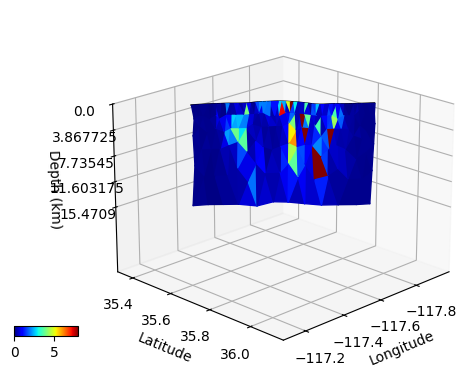

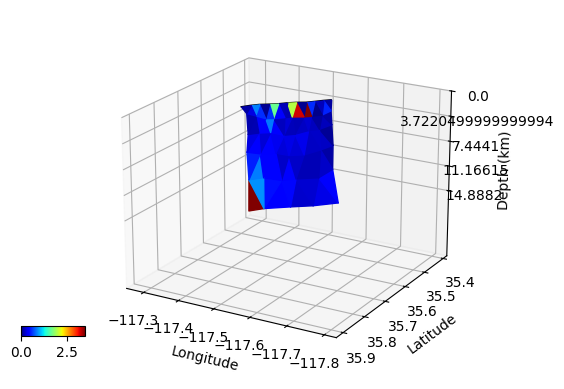

Cannot plot ellipses or quiverkey if scale is None


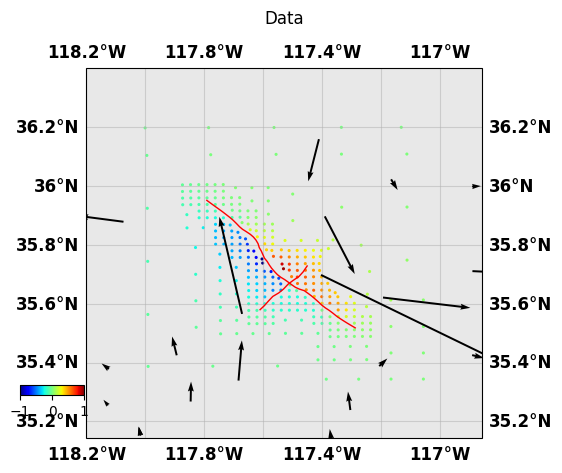

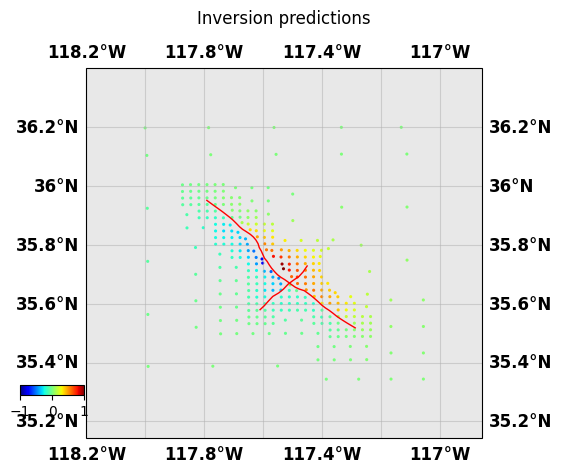

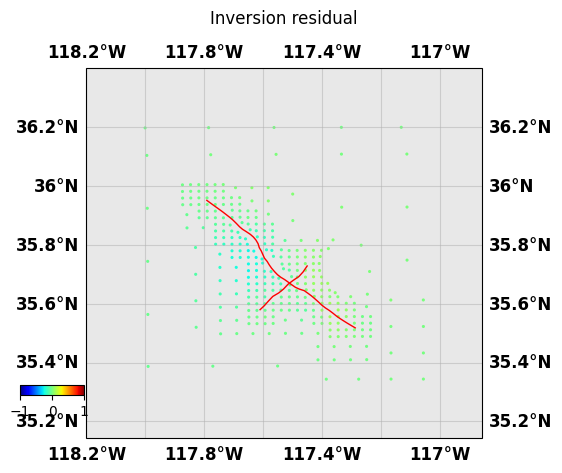

In [11]:
faults[0].plot(view=(20., 45.), slip="strikeslip", plot_on_2d=False, norm=(0., 8.))
faults[1].plot(view=(20., 120.), slip="strikeslip", plot_on_2d=False, norm=(0., 3.5))

datasets[1].plot(markersize=5., data="data", title="Data", norm=(-1., 1.), faults=faults, gps=datasets[2])
datasets[1].plot(markersize=5., data="synth", title="Inversion predictions", norm=(-1., 1.), faults=faults)
datasets[1].plot(markersize=5., data="res", title="Inversion residual", norm=(-1., 1.), faults=faults)

## Visualisations

/Users/hintont/Dev/projects/ridgecrest/scripts/utils.py:149: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  dep3=[]


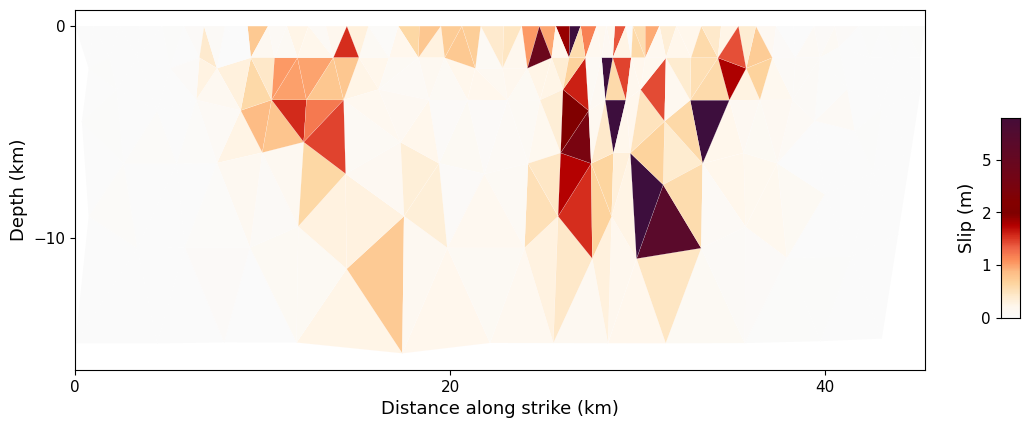

In [19]:
from utils import plotSlip2D

plotSlip2D(faults[0], save_path=f"../results/inversion_results/{dirname}/slip_2d_main.pdf", slip='ss', valmax=5.)

center [np.float64(74.72795174077247), np.float64(-0.0)]
L 5.1569666666666665
coords [array([7.92      , 2.47224319]), array([8.33000762, 2.6420739 ]), array([8.77, 2.7 ]), array([9.20999238, 2.6420739 ]), array([9.62      , 2.47224319]), array([9.4075    , 2.10418239]), array([9.195     , 1.73612159]), array([8.9825   , 1.3680608])]


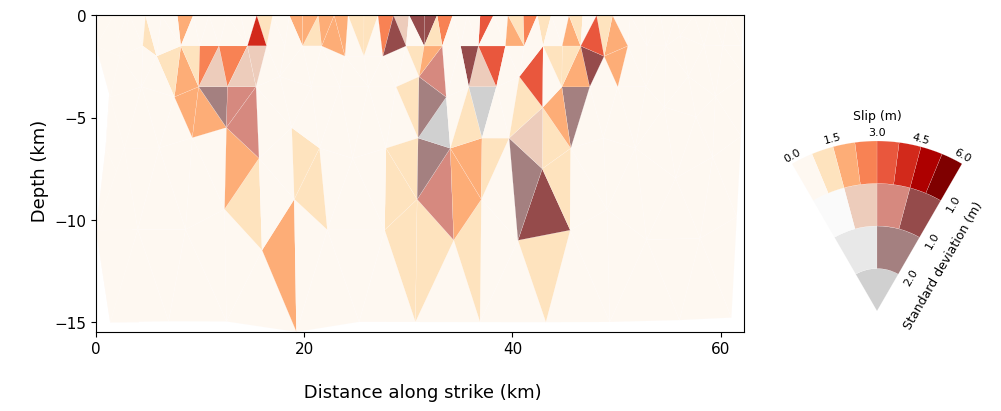

In [23]:
from utils import plotSlipBivariate
sigma = np.std(res["ParameterSets"]["strikeslipmain"], axis=0)

# plot slip bivariate
plotSlipBivariate(faults[0], sigma, save_path=f"../results/inversion_results/{dirname}/slip_2d_bivariate.pdf", slip='strikeslip', valmax=6., sigmamax=2.)

Carefull: there is no NaNs, the interpolation might be a whole load of garbage...


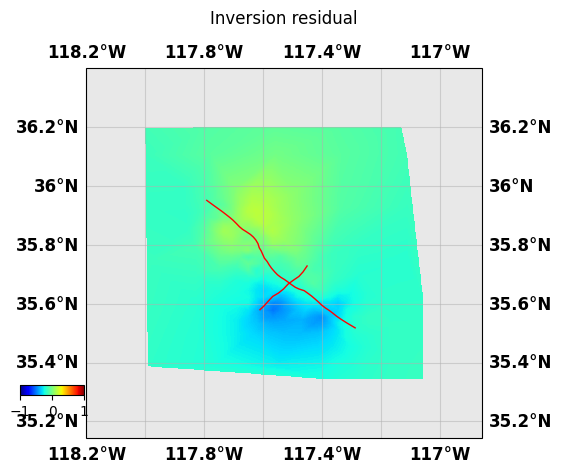

In [15]:
datasets[0].plot(markersize=2.5, data="res", title="Inversion residual", norm=(-1., 1.), faults=faults, plotType="flat")

## Animations

In [46]:
## First, take all of the step files and create 2d arrays of slip and sigma (i.e. slip and sigma at each patch for each step)
import os
h5_filenames = [f for f in os.listdir(f"../results/inversion_results/{dirname}/outputs/") if f.endswith('.h5')]
h5_filenames.sort()  # Ensure files are in order
# print(h5_filenames)

slips = np.empty((len(h5_filenames), res["ParameterSets"]["strikeslipmain"].shape[1]))
sigmas = np.empty((len(h5_filenames), res["ParameterSets"]["strikeslipmain"].shape[1]))
for i, filename in enumerate(h5_filenames):
    print(f"Processing file {i+1}/{len(h5_filenames)}: {filename}...")
    with h5py.File(f"../results/inversion_results/{dirname}/outputs/{filename}", "r") as f:
        slips[i] = -soln(f["ParameterSets"]["strikeslipmain"], method="median")
        sigmas[i] = np.std(f["ParameterSets"]["strikeslipmain"], axis=0)

## store in pickle
with open(f"../results/inversion_results/{dirname}/slips_sigmas.pickle", "wb") as f:
    pickle.dump((slips, sigmas), f)

Processing file 1/31: step_000.h5...
Processing file 2/31: step_005.h5...
Processing file 3/31: step_010.h5...
Processing file 4/31: step_015.h5...
Processing file 5/31: step_020.h5...
Processing file 6/31: step_025.h5...
Processing file 7/31: step_030.h5...
Processing file 8/31: step_035.h5...
Processing file 9/31: step_040.h5...
Processing file 10/31: step_045.h5...
Processing file 11/31: step_050.h5...
Processing file 12/31: step_055.h5...
Processing file 13/31: step_060.h5...
Processing file 14/31: step_065.h5...
Processing file 15/31: step_070.h5...
Processing file 16/31: step_075.h5...
Processing file 17/31: step_080.h5...
Processing file 18/31: step_085.h5...
Processing file 19/31: step_090.h5...
Processing file 20/31: step_095.h5...
Processing file 21/31: step_100.h5...
Processing file 22/31: step_105.h5...
Processing file 23/31: step_110.h5...
Processing file 24/31: step_115.h5...
Processing file 25/31: step_120.h5...
Processing file 26/31: step_125.h5...
Processing file 27/31

coords [array([7.92      , 2.47224319]), array([8.33000762, 2.6420739 ]), array([8.77, 2.7 ]), array([9.20999238, 2.6420739 ]), array([9.62      , 2.47224319]), array([9.4075    , 2.10418239]), array([9.195     , 1.73612159]), array([8.9825   , 1.3680608])]


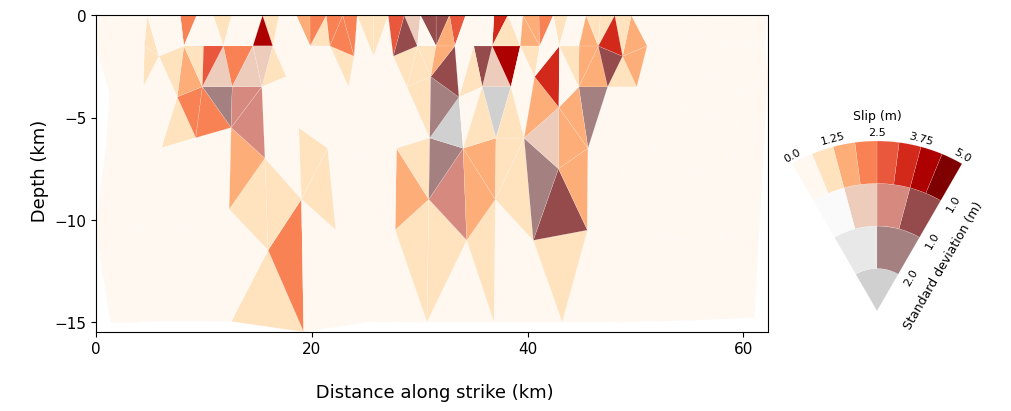

In [48]:
from utils import animateSlipConvergenceBivariate
animateSlipConvergenceBivariate(faults[0], slips, sigmas, save_path=f"../results/inversion_results/{dirname}/slip_convergence_bivariate_.mp4", slip='strikeslip', valmax=5., sigmamax=2.)